## Cognitive Load Research Paper

### 1. Setup & Imports

In [1]:
import sys
import os

# Add the project root to sys.path
sys.path.append(os.path.abspath(os.path.join(os.path.dirname("__file__"), "..")))


In [19]:
%load_ext autoreload
%autoreload 2

import numpy as np
from src.load_data import load_mat_epochs, load_stew_epochs
from src.preprocess import preprocess_epochs
from src.custom_ssa import batch_decompose_cissa
from src.sampling import undersample
from src.feature_selection import run_bhho_feature_selection
from src.classification import evaluate_selected_features, plot_confusion_matrix


import logging
logging.basicConfig(level=logging.INFO)


### 2. Data Loading

In [3]:
ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_DIR = os.path.join(ROOT_DIR, "data", "raw")
mat_dir = os.path.join(DATA_DIR, "MAT Dataset")
stew_dir = os.path.join(DATA_DIR, "STEW Dataset")

# Load MAT with 50% overlap
X_mat, y_mat = load_mat_epochs(mat_dir, resample_sfreq=128, overlap=0.5)

# Load STEW with 50% overlap
X_stew, y_stew = load_stew_epochs(stew_dir, sfreq=256, overlap=0.5)

### 3. Preprocessing

In [4]:
# Preprocess _and_ filter labels
X_mat_clean, y_mat_clean   = preprocess_epochs(X_mat, y_mat,   sfreq=128.0, artifact_threshold=100.0)
X_stew_clean, y_stew_clean = preprocess_epochs(X_stew, y_stew, sfreq=256.0, artifact_threshold=100.0)


### 4. SSA & Feature Extraction

In [5]:
X_mat_ssa = batch_decompose_cissa(X_mat_clean, n_imfs=3, n_jobs=-1)
X_stew_ssa = batch_decompose_cissa(X_stew_clean, n_imfs=3, n_jobs=-1)

In [ ]:
import logging
import numpy as np
from scipy.stats import skew, kurtosis
from scipy.signal import welch
import antropy as ant
from joblib import Parallel, delayed

# ── Logging setup ─────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)-8s %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger(__name__)

def extract_features_cissa_light(
    X_cissa: np.ndarray,
    sfreq: float = 128.0,
    bands=None,
    n_jobs: int = -1,
    ds: int = 4,
    nperseg: int = 64,
    chunk_size: int = 1000
) -> np.ndarray:
    """
    Ultra‐light feature extractor with progress logging.
      • downsample each signal by factor ds
      • drop fractal dims (Higuchi, Petrosian)
      • PSD window nperseg=64
      • process flattened signals in chunks of chunk_size
      • log an INFO line after each chunk
    """
    # 1) Prep and flatten
    n_epochs, n_comps, n_samples = X_cissa.shape
    Xds   = X_cissa[..., ::ds]
    n_s    = Xds.shape[-1]
    flat  = Xds.reshape(-1, n_s)
    total = flat.shape[0]

    # 2) Build band masks once
    if bands is None:
        bands = [(1,4),(4,8),(8,13),(13,30),(30,40)]
    f0, _     = welch(np.zeros(n_s), fs=sfreq, nperseg=nperseg)
    band_masks = [ (f0>=lo)&(f0<hi) for lo,hi in bands ]

    # 3) Figure out feature‐vector length analytically:
    #    4 time‐stats + 3 Hjorth + 3 entropies + len(bands) band‐powers
    n_feats = 4 + 3 + 3 + len(band_masks)
    feats_flat = np.zeros((total, n_feats), dtype=np.float64)

    # 4) Per‐signal compute (no warm‐up needed)
    def _compute(sig):
        out = [
            sig.mean(), sig.std(),
            skew(sig), kurtosis(sig),
        ]
        # Hjorth
        d1 = np.diff(sig); d2 = np.diff(sig, 2)
        v0, v1, v2 = np.var(sig), np.var(d1), np.var(d2)
        mob        = np.sqrt(v1/v0) if v0>0 else 0.0
        comp       = (np.sqrt(v2/v1)/mob) if (v1>0 and mob>0) else 0.0
        out += [v0, mob, comp]

        # entropies
        out += [
            ant.sample_entropy(sig, metric="chebyshev"),  # let it fallback to Python if numba mismatches
            ant.perm_entropy(sig, order=3, delay=1, normalize=True),
            ant.spectral_entropy(sig, sfreq, method='welch', nperseg=nperseg, normalize=True),
        ]

        # band‐powers
        f, Pxx = welch(sig, fs=sfreq, nperseg=nperseg)
        for mask in band_masks:
            out.append(np.trapz(Pxx[mask], f[mask]))

        return np.array(out, dtype=np.float64)

    # 5) Process in chunks, logging after each
    for start in range(0, total, chunk_size):
        end = min(start + chunk_size, total)
        block = flat[start:end]
        results = Parallel(n_jobs=n_jobs)(
            delayed(_compute)(sig) for sig in block
        )
        feats_flat[start:end] = np.vstack(results)
        logger.info(f"Processed signals {start:,d}–{end:,d} of {total:,d}")

    # 6) Reshape back to (n_epochs, n_comps * n_feats)
    return feats_flat.reshape(n_epochs, n_comps * n_feats)

      

X_mat_features = extract_features_cissa_light(X_mat_ssa, sfreq=128, n_jobs=-1)
X_stew_features = extract_features_cissa_light(X_stew_ssa, sfreq=256, n_jobs=-1)



C:\Users\Tony\AppData\Roaming\Python\Python310\site-packages\scipy\signal\_spectral_py.py:600: UserWarning: nperseg = 64 is greater than input length  = 32, using nperseg = 32
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
2025-05-12 00:39:30 __main__ INFO     Processed signals 0–1,000 of 1,088,640
2025-05-12 00:39:31 __main__ INFO     Processed signals 1,000–2,000 of 1,088,640
2025-05-12 00:39:32 __main__ INFO     Processed signals 2,000–3,000 of 1,088,640
2025-05-12 00:39:33 __main__ INFO     Processed signals 3,000–4,000 of 1,088,640
2025-05-12 00:39:34 __main__ INFO     Processed signals 4,000–5,000 of 1,088,640
2025-05-12 00:39:35 __main__ INFO     Processed signals 5,000–6,000 of 1,088,640
2025-05-12 00:39:35 __main__ INFO     Processed signals 6,000–7,000 of 1,088,640
2025-05-12 00:39:36 __main__ INFO     Processed signals 7,000–8,000 of 1,088,640
2025-05-12 00:39:37 __main__ INFO     Processed signals 8,000–9,000 of 1,088,640
2025-05-12 00:39:37 __main_

#### 4.1. Undersampling

In [27]:
X_mat_bal,  y_mat_bal  = undersample(X_mat_features, y_mat_clean, random_state=42)
X_stew_bal, y_stew_bal = undersample(X_stew_features, y_stew_clean, random_state=42)

In [28]:

# Clean NaNs / Infs
def clean_features(X):
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    return X.astype(np.float64)

X_mat_clean  = clean_features(X_mat_bal)
X_stew_clean = clean_features(X_stew_bal)

In [29]:
from src.feature_normalization import FeatureNormalizer
normalizer = FeatureNormalizer()
X_mat_norm  = normalizer.fit_transform(X_mat_clean)
X_stew_norm = normalizer.fit_transform(X_stew_clean)
print(X_mat_norm.shape, y_mat_bal.shape)
print(X_stew_norm.shape, y_stew_bal.shape)

(8856, 945) (8856,)
(6256, 630) (6256,)


### 5. Feature Selection

In [30]:
%reload_ext autoreload

from src.feature_selection import run_bhho_feature_selection

best_mask_mat_S, best_acc_mat_S = run_bhho_feature_selection(
    X_mat_norm, y_mat_bal,
    pop_size=20, max_iter=30,
    transfer='S', k=5, cv=10
)
print(f"MAT (S-transfer): selected {best_mask_mat_S.sum()} features, CV acc = {best_acc_mat_S:.4f}")

best_mask_stew_S, best_acc_stew_S = run_bhho_feature_selection(
    X_stew_norm, y_stew_bal,
    pop_size=20, max_iter=30,
    transfer='S', k=5, cv=10
)
print(f"STEW (S-transfer): selected {best_mask_stew_S.sum()} features, CV acc = {best_acc_stew_S:.4f}")


2025-05-12 01:04:50 src.bhho2 INFO     Initial best score = 0.6020 (hawk 1)
2025-05-12 01:04:50 src.bhho2 INFO     --- Iteration 1/30 ---
2025-05-12 01:05:06 src.bhho2 INFO     --- Iteration 2/30 ---
2025-05-12 01:05:22 src.bhho2 INFO     --- Iteration 3/30 ---
2025-05-12 01:05:39 src.bhho2 INFO     --- Iteration 4/30 ---
2025-05-12 01:05:56 src.bhho2 INFO     --- Iteration 5/30 ---
2025-05-12 01:06:12 src.bhho2 INFO     --- Iteration 6/30 ---
2025-05-12 01:06:29 src.bhho2 INFO     --- Iteration 7/30 ---
2025-05-12 01:06:43 src.bhho2 INFO     New best! Iter 7, hawk[16] → score = 0.6028
2025-05-12 01:06:46 src.bhho2 INFO     --- Iteration 8/30 ---
2025-05-12 01:07:04 src.bhho2 INFO     --- Iteration 9/30 ---
2025-05-12 01:07:21 src.bhho2 INFO     --- Iteration 10/30 ---
2025-05-12 01:07:38 src.bhho2 INFO     --- Iteration 11/30 ---
2025-05-12 01:07:54 src.bhho2 INFO     --- Iteration 12/30 ---
2025-05-12 01:08:12 src.bhho2 INFO     --- Iteration 13/30 ---
2025-05-12 01:08:29 src.bhho2 I

MAT (S-transfer): selected 710 features, CV acc = 0.6055


2025-05-12 01:14:05 src.bhho2 INFO     Initial best score = 0.6250 (hawk 13)
2025-05-12 01:14:05 src.bhho2 INFO     --- Iteration 1/30 ---
2025-05-12 01:14:12 src.bhho2 INFO     --- Iteration 2/30 ---
2025-05-12 01:14:16 src.bhho2 INFO     New best! Iter 2, hawk[9] → score = 0.6255
2025-05-12 01:14:20 src.bhho2 INFO     --- Iteration 3/30 ---
2025-05-12 01:14:21 src.bhho2 INFO     New best! Iter 3, hawk[3] → score = 0.6301
2025-05-12 01:14:28 src.bhho2 INFO     --- Iteration 4/30 ---
2025-05-12 01:14:36 src.bhho2 INFO     --- Iteration 5/30 ---
2025-05-12 01:14:44 src.bhho2 INFO     --- Iteration 6/30 ---
2025-05-12 01:14:52 src.bhho2 INFO     --- Iteration 7/30 ---
2025-05-12 01:14:59 src.bhho2 INFO     --- Iteration 8/30 ---
2025-05-12 01:15:07 src.bhho2 INFO     --- Iteration 9/30 ---
2025-05-12 01:15:16 src.bhho2 INFO     --- Iteration 10/30 ---
2025-05-12 01:15:24 src.bhho2 INFO     --- Iteration 11/30 ---
2025-05-12 01:15:32 src.bhho2 INFO     --- Iteration 12/30 ---
2025-05-12 0

STEW (S-transfer): selected 445 features, CV acc = 0.6325


In [ ]:
best_mask_mat_V, best_acc_mat_V = run_bhho_feature_selection(
    X_mat_norm, y_mat_bal,
    pop_size=20, max_iter=30,
    transfer='V', k=5, cv=10
)
print(f"MAT (V-transfer): selected {best_mask_mat_V.sum()} features, CV acc = {best_acc_mat_V:.4f}")

best_mask_stew_V, best_acc_stew_V = run_bhho_feature_selection(
    X_stew_norm, y_stew_bal,
    pop_size=20, max_iter=30,
    transfer='V', k=5, cv=10
)
print(f"STEW (V-transfer): selected {best_mask_stew_V.sum()} features, CV acc = {best_acc_stew_V:.4f}")

2025-05-12 01:18:26 src.bhho2 INFO     Initial best score = 0.5950 (hawk 15)
2025-05-12 01:18:26 src.bhho2 INFO     --- Iteration 1/30 ---
2025-05-12 01:18:32 src.bhho2 INFO     New best! Iter 1, hawk[10] → score = 0.6025
2025-05-12 01:18:38 src.bhho2 INFO     --- Iteration 2/30 ---
2025-05-12 01:18:40 src.bhho2 INFO     New best! Iter 2, hawk[2] → score = 0.6057
2025-05-12 01:18:50 src.bhho2 INFO     --- Iteration 3/30 ---
2025-05-12 01:19:01 src.bhho2 INFO     --- Iteration 4/30 ---
2025-05-12 01:19:12 src.bhho2 INFO     --- Iteration 5/30 ---
2025-05-12 01:19:23 src.bhho2 INFO     --- Iteration 6/30 ---
2025-05-12 01:19:35 src.bhho2 INFO     --- Iteration 7/30 ---
2025-05-12 01:19:46 src.bhho2 INFO     --- Iteration 8/30 ---
2025-05-12 01:20:01 src.bhho2 INFO     --- Iteration 9/30 ---
2025-05-12 01:20:16 src.bhho2 INFO     --- Iteration 10/30 ---
2025-05-12 01:20:28 src.bhho2 INFO     --- Iteration 11/30 ---
2025-05-12 01:20:40 src.bhho2 INFO     --- Iteration 12/30 ---
2025-05-12 

MAT (V-transfer): selected 377 features, CV acc = 0.6094


2025-05-12 01:25:11 src.bhho2 INFO     Initial best score = 0.6210 (hawk 14)
2025-05-12 01:25:11 src.bhho2 INFO     --- Iteration 1/30 ---
2025-05-12 01:25:11 src.bhho2 INFO     New best! Iter 1, hawk[0] → score = 0.6226
2025-05-12 01:25:18 src.bhho2 INFO     New best! Iter 1, hawk[19] → score = 0.6248
2025-05-12 01:25:18 src.bhho2 INFO     --- Iteration 2/30 ---
2025-05-12 01:25:24 src.bhho2 INFO     --- Iteration 3/30 ---
2025-05-12 01:25:31 src.bhho2 INFO     --- Iteration 4/30 ---
2025-05-12 01:25:37 src.bhho2 INFO     --- Iteration 5/30 ---
2025-05-12 01:25:43 src.bhho2 INFO     --- Iteration 6/30 ---
2025-05-12 01:25:45 src.bhho2 INFO     New best! Iter 6, hawk[5] → score = 0.6293
2025-05-12 01:25:49 src.bhho2 INFO     --- Iteration 7/30 ---
2025-05-12 01:25:54 src.bhho2 INFO     --- Iteration 8/30 ---
2025-05-12 01:26:01 src.bhho2 INFO     --- Iteration 9/30 ---
2025-05-12 01:26:06 src.bhho2 INFO     --- Iteration 10/30 ---
2025-05-12 01:26:12 src.bhho2 INFO     --- Iteration 11

### 6. Final Evaluation

=== MAT (Balanced) Classification Report ===
              precision    recall  f1-score   support

        Rest       0.55      0.59      0.57      4428
        Task       0.56      0.52      0.54      4428

    accuracy                           0.55      8856
   macro avg       0.55      0.55      0.55      8856
weighted avg       0.55      0.55      0.55      8856



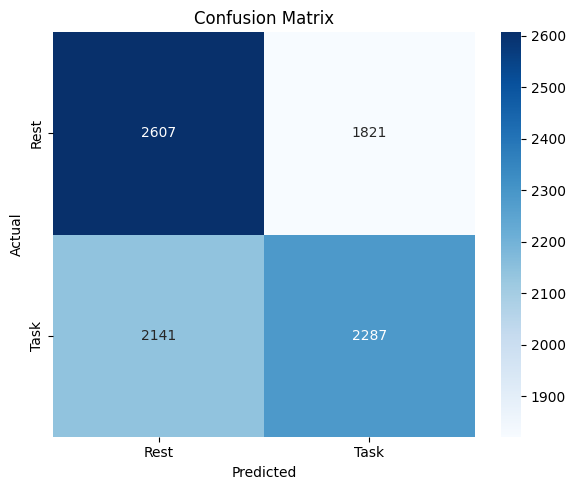

=== STEW (Balanced) Classification Report ===
              precision    recall  f1-score   support

        Rest       0.62      0.55      0.58      3128
        Task       0.59      0.67      0.63      3128

    accuracy                           0.61      6256
   macro avg       0.61      0.61      0.60      6256
weighted avg       0.61      0.61      0.60      6256



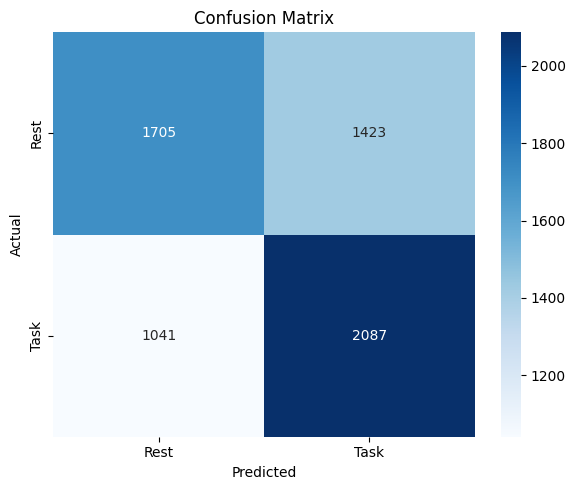

In [ ]:
# Evaluate on the balanced MAT set
report_mat_bal, cm_mat_bal = evaluate_selected_features(
    X_mat_bal,   # balanced feature matrix
    y_mat_bal,   # balanced labels
    best_mask_mat_S  # mask found on balanced data
)
print("=== MAT (Balanced) Classification Report ===")
print(report_mat_bal)
plot_confusion_matrix(cm_mat_bal, labels=["Rest","Task"])

# Evaluate on the balanced STEW set
report_stew_bal, cm_stew_bal = evaluate_selected_features(
    X_stew_bal,    # balanced feature matrix
    y_stew_bal,    # balanced labels
    best_mask_stew_S
)
print("=== STEW (Balanced) Classification Report ===")
print(report_stew_bal)
plot_confusion_matrix(cm_stew_bal, labels=["Rest","Task"])


### 7. Plots & Analysis